In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
import cv2

# 1. Charger la Dice Loss pour le chargement du modèle
def dice_loss(y_true, y_pred):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1. - (2. * intersection + 1.) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1.)

# 2. Charger le modèle entraîné
model = tf.keras.models.load_model('../models/unet_spacenet_v1.keras', 
                                   custom_objects={'dice_loss': dice_loss})
print("Modèle prêt pour l'extraction !")

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Modèle prêt pour l'extraction !


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


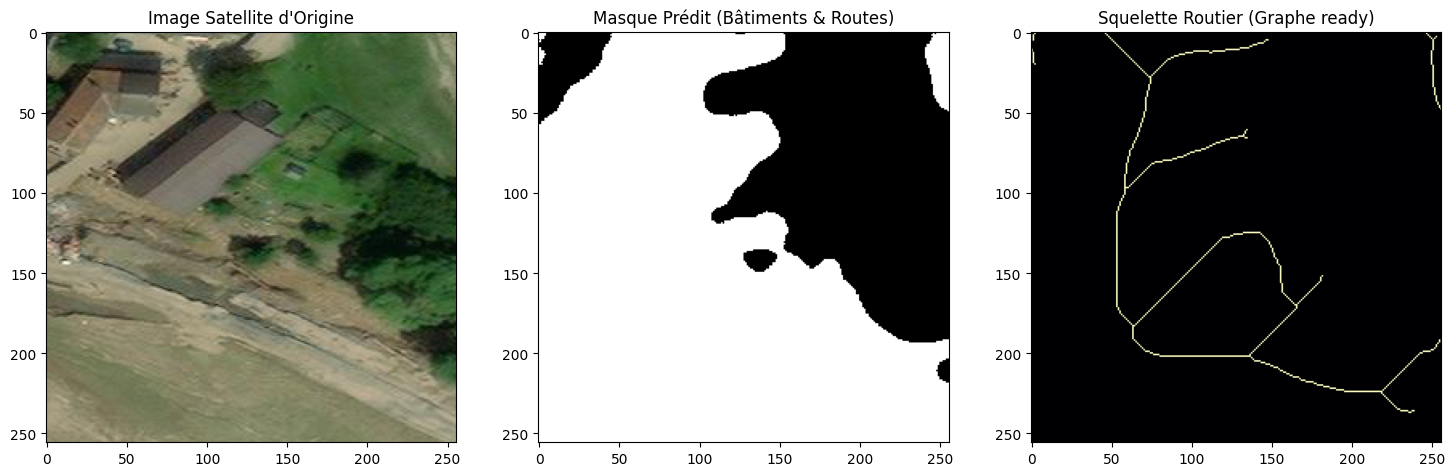

In [3]:
# 1. Charger un échantillon de données
X = np.load('../data/processed/X_train_sample.npy')
idx = 8 # On reprend le patch avec la route bien visible
sample_img = X[idx:idx+1] 

# 2. Prédire le masque binaire
mask_pred = model.predict(sample_img)[0].squeeze()
binary_mask = (mask_pred > 0.5).astype(np.uint8)

# 3. Squelettisation (Morphologie mathématique)
# On transforme les zones blanches épaisses en lignes fines
skeleton = skeletonize(binary_mask)

# 4. Affichage du résultat final du Module 3
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(sample_img[0])
plt.title("Image Satellite d'Origine")

plt.subplot(1, 3, 2)
plt.imshow(binary_mask, cmap='gray')
plt.title("Masque Prédit (Bâtiments & Routes)")

plt.subplot(1, 3, 3)
plt.imshow(skeleton, cmap='magma')
plt.title("Squelette Routier (Graphe ready)")

plt.show()

In [14]:
import os

# 1. Chemin vers tes données traitées
PROCESSED_PATH = '../data/processed/'

# 2. Chargement de Y (les masques de vérité terrain)
if os.path.exists(os.path.join(PROCESSED_PATH, 'Y_train_sample.npy')):
    Y = np.load(os.path.join(PROCESSED_PATH, 'Y_train_sample.npy'))
    print(f"✅ Variable 'Y' chargée avec succès ! Taille : {Y.shape}")
else:
    print("❌ Erreur : Le fichier Y_train_sample.npy est introuvable.")

✅ Variable 'Y' chargée avec succès ! Taille : (11, 256, 256)


In [16]:
# 1. On s'assure que le modèle est chargé
import tensorflow as tf
import numpy as np

# On définit la Dice Loss pour que Keras puisse charger le modèle
def dice_loss(y_true, y_pred):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1. - (2. * intersection + 1.) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1.)

# Charger le modèle
model = tf.keras.models.load_model('../models/unet_spacenet_v1.keras', 
                                   custom_objects={'dice_loss': dice_loss})

# 2. On prépare les données (X et Y)
X = np.load('../data/processed/X_train_sample.npy')
Y = np.load('../data/processed/Y_train_sample.npy')

# 3. GÉNÉRATION DE 'preds'
# On fait prédire le modèle sur le patch #8
idx = 8
# On ajoute une dimension [1, 256, 256, 3] car le modèle attend un batch
preds = model.predict(X[idx:idx+1]) 

print(f"✅ 'preds' généré avec succès ! Taille : {preds.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
✅ 'preds' généré avec succès ! Taille : (1, 256, 256, 1)


📊 SCORE IoU : 0.1381


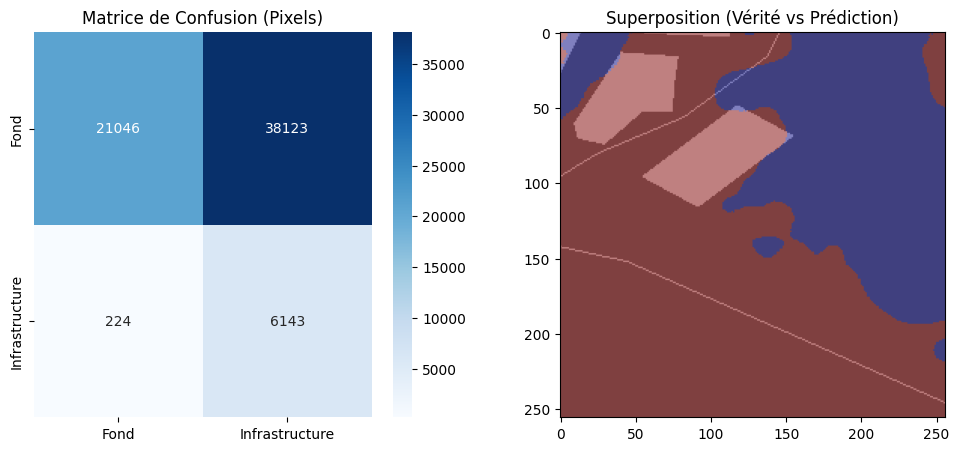

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# --- 1. CALCUL DU SCORE IoU ---
def calculate_iou(y_true, y_pred):
    y_true_f = (y_true.flatten() > 0.5).astype(int)
    y_pred_f = (y_pred.flatten() > 0.5).astype(int)
    intersection = np.sum(y_true_f * y_pred_f)
    union = np.sum(y_true_f) + np.sum(y_pred_f) - intersection
    return intersection / (union + 1e-7)

# On calcule l'IoU sur le patch actuel (idx=8 par exemple)
iou_val = calculate_iou(Y[8], preds[0])
print(f"📊 SCORE IoU : {iou_val:.4f}")

# --- 2. MATRICE DE CONFUSION ---
plt.figure(figsize=(12, 5))

# Sous-plot pour la matrice
plt.subplot(1, 2, 1)
y_true_flat = (Y[8].flatten() > 0.5).astype(int)
y_pred_flat = (preds[0].flatten() > 0.5).astype(int)
cm = confusion_matrix(y_true_flat, y_pred_flat)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fond', 'Infrastructure'], 
            yticklabels=['Fond', 'Infrastructure'])
plt.title('Matrice de Confusion (Pixels)')

# Sous-plot pour comparer visuellement
plt.subplot(1, 2, 2)
plt.imshow(Y[8].squeeze(), cmap='gray', alpha=0.5)
plt.imshow(preds[0].squeeze() > 0.5, cmap='jet', alpha=0.5)
plt.title('Superposition (Vérité vs Prédiction)')

plt.show()

In [5]:
!pip install skan
import networkx as nx
from skan import Skeleton, summarize

# 1. Analyser le squelette pour extraire les branches
# 'Skeleton' transforme l'image binaire thinned en une structure de données
skel_obj = Skeleton(skeleton)
stats = summarize(skel_obj)

print("Statistiques du réseau routier extrait :")
print(stats.head())

# 2. Création d'un graphe NetworkX
# Cela permet de calculer des distances et des chemins les plus courts
G = nx.Graph()

for index, row in stats.iterrows():
    # On ajoute une arête entre le nœud de début et le nœud de fin de chaque segment
    node_a = (row['node-id-src'])
    node_b = (row['node-id-dst'])
    dist = row['branch-distance']
    G.add_edge(node_a, node_b, weight=dist)

print(f"\nGraphe créé avec {G.number_of_nodes()} nœuds et {G.number_of_edges()} segments de route.")

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 2.8 MB/s eta 0:00:01
   --------------- ------------------------ 1.0/2.7 MB 2.8 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.7 MB 2.8 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.7 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 2.7 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 2.7 MB/s eta 0:00:14
   - -------------------------------------

C:\Users\DELL\AppData\Local\Temp\ipykernel_28372\2925969255.py:8: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  stats = summarize(skel_obj)


Statistiques du réseau routier extrait :
   skeleton-id  node-id-src  node-id-dst  branch-distance  branch-type  \
0            0            0           17         5.828427            0   
1            1            1          148        40.183766            1   
2            2            2           21         6.656854            1   
3            2           12           21         2.828427            1   
4            1           20          148        83.355339            1   

   mean-pixel-value  stdev-pixel-value  image-coord-src-0  image-coord-src-1  \
0               1.0                0.0                  0                  3   
1               1.0                0.0                  0                 46   
2               1.0                0.0                  0                246   
3               1.0                0.0                  3                252   
4               1.0                0.0                  5                147   

   image-coord-dst-0  image-coord

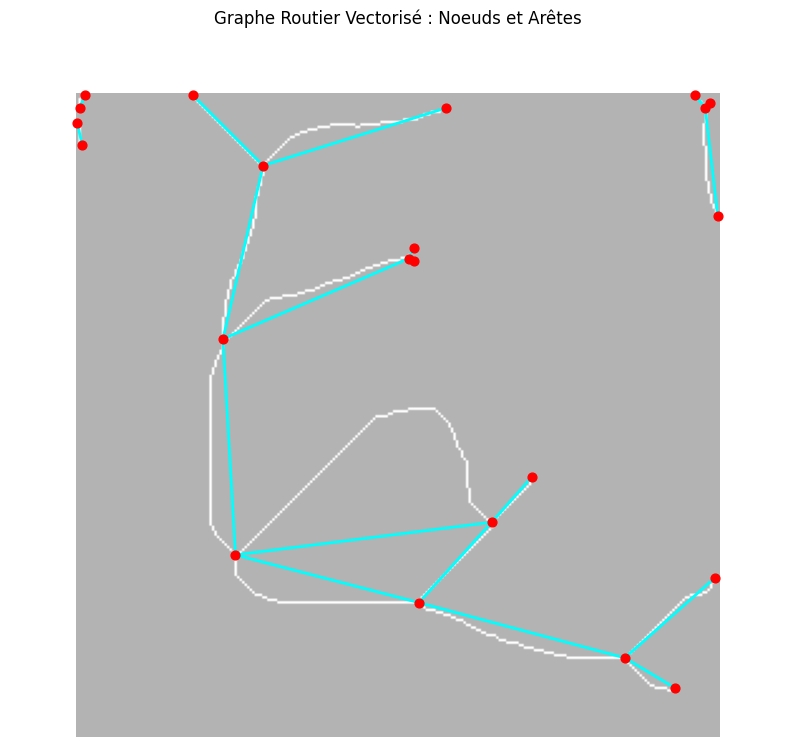

Visualisation réussie pour 22 positions de nœuds.


In [7]:
import networkx as nx

# 1. Construction d'un dictionnaire de positions complet
# On parcourt chaque ligne pour enregistrer la source ET la destination
pos = {}
for _, row in stats.iterrows():
    # Coordonnées pour le nœud source (x = coord-1, y = coord-0)
    pos[int(row['node-id-src'])] = (row['image-coord-src-1'], row['image-coord-src-0'])
    # Coordonnées pour le nœud destination
    pos[int(row['node-id-dst'])] = (row['image-coord-dst-1'], row['image-coord-dst-0'])

# 2. Conversion des nœuds du graphe en entiers (pour correspondre à 'pos')
# Parfois skan mélange les types float/int, on harmonise tout ici
G_int = nx.relabel_nodes(G, lambda x: int(x))

# 3. Dessiner le graphe
plt.figure(figsize=(10, 10))
plt.imshow(skeleton, cmap='gray', alpha=0.3) # Squelette en fond discret

# Dessin des segments (routes) en cyan
nx.draw_networkx_edges(G_int, pos, edge_color='cyan', width=2)

# Dessin des intersections en rouge
nx.draw_networkx_nodes(G_int, pos, node_size=40, node_color='red')

plt.title("Graphe Routier Vectorisé : Noeuds et Arêtes")
plt.axis('off')
plt.show()

print(f"Visualisation réussie pour {len(pos)} positions de nœuds.")

Statistiques finales du réseau :
- Nombre de nœuds après nettoyage : 14
- Longueur totale des routes : 866.13 pixels


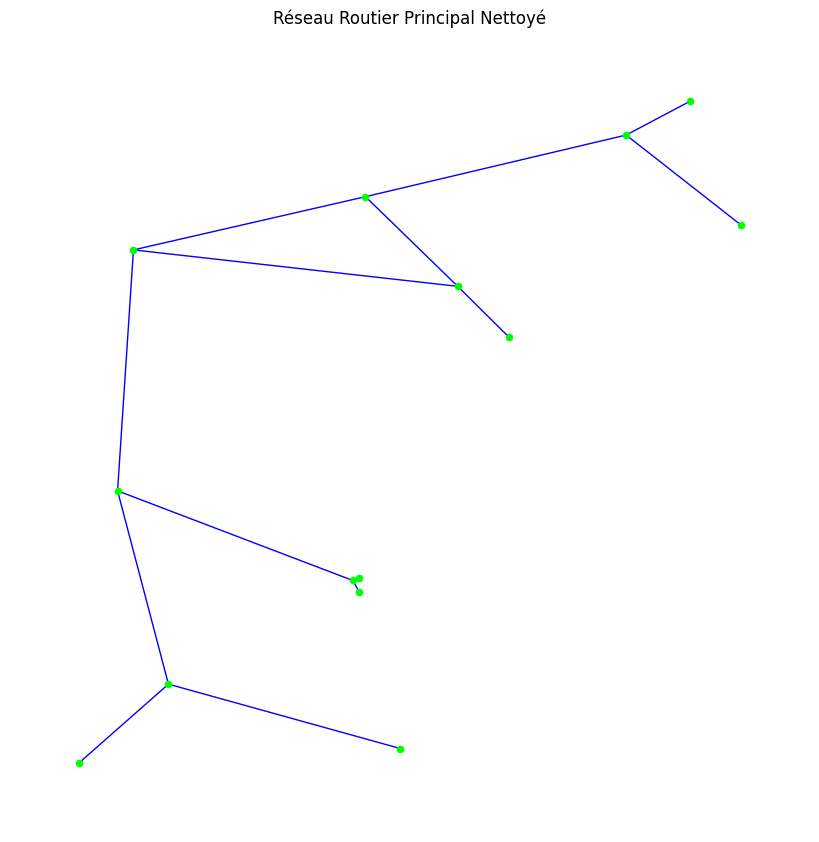

In [8]:
# 1. Nettoyage : On ne garde que la "composante géante" (le plus grand réseau connecté)
if G_int.number_of_nodes() > 0:
    largest_cc = max(nx.connected_components(G_int), key=len)
    G_cleaned = G_int.subgraph(largest_cc).copy()
else:
    G_cleaned = G_int

# 2. Calcul de la longueur totale du réseau (en pixels)
total_length = sum(d['weight'] for u, v, d in G_cleaned.edges(data=True))

print(f"Statistiques finales du réseau :")
print(f"- Nombre de nœuds après nettoyage : {G_cleaned.number_of_nodes()}")
print(f"- Longueur totale des routes : {total_length:.2f} pixels")

# 3. Visualisation du réseau principal uniquement
plt.figure(figsize=(8, 8))
nx.draw(G_cleaned, pos, node_size=20, node_color='lime', edge_color='blue')
plt.title("Réseau Routier Principal Nettoyé")
plt.show()

Itinéraire trouvé entre le nœud 1 et 798
Distance à parcourir : 411.08 pixels


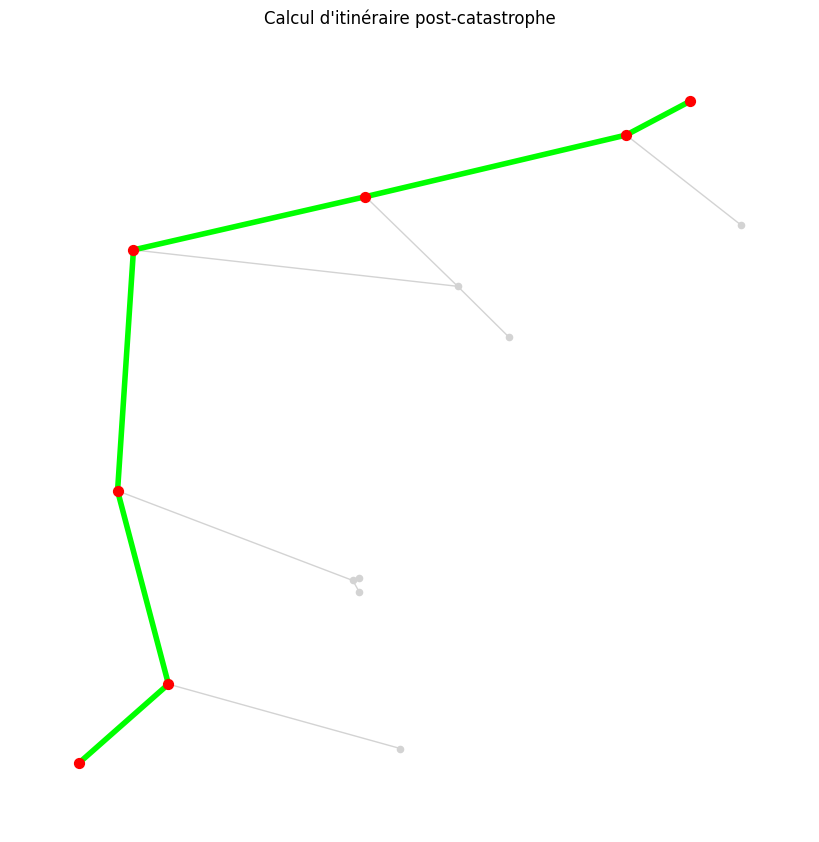

In [12]:
# 1. Choisir deux nœuds au hasard dans le graphe nettoyé
nodes = list(G_cleaned.nodes())
start_node = nodes[0]
end_node = nodes[-1]

# 2. Calculer le chemin le plus court (Dijkstra)
shortest_path = nx.shortest_path(G_cleaned, source=start_node, target=end_node, weight='weight')
path_length = nx.shortest_path_length(G_cleaned, source=start_node, target=end_node, weight='weight')

print(f"Itinéraire trouvé entre le nœud {start_node} et {end_node}")
print(f"Distance à parcourir : {path_length:.2f} pixels")

# 3. Visualisation du chemin en couleur
plt.figure(figsize=(8, 8))
# Dessiner tout le réseau en gris
nx.draw(G_cleaned, pos, node_size=20, node_color='lightgray', edge_color='lightgray')
# Dessiner le chemin le plus court en vert fluo
path_edges = list(zip(shortest_path, shortest_path[1:]))
nx.draw_networkx_nodes(G_cleaned, pos, nodelist=shortest_path, node_color='red', node_size=50)
nx.draw_networkx_edges(G_cleaned, pos, edgelist=path_edges, edge_color='lime', width=4)

plt.title("Calcul d'itinéraire post-catastrophe")
plt.show()